In [1]:
from pathlib import Path
import json
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    CSVLogger,
)


SEED = 12345
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = 35

EPOCHS = 400
PATIENCE = 200
LEARNING_RATE = 1e-7

RUN_NAME = "mobilenet_bn_locked_oversampling_seed12345"

OUTPUT_DIR = Path("/kaggle/working") / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tf.keras.utils.set_random_seed(SEED)


print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Output:", OUTPUT_DIR)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Output: /kaggle/working/mobilenet_bn_locked_oversampling_seed12345


In [2]:
KAGGLE_INPUT = Path("/kaggle/input")


MANIFEST_PATH = next(
    KAGGLE_INPUT.rglob("zoolake_clean_split_manifest.csv")
)

CLASS_NAMES_PATH = next(
    KAGGLE_INPUT.rglob("zoolake_class_names.json")
)

DATASET_ROOT = next(
    KAGGLE_INPUT.rglob("zooplankton_0p5x")
)


# Επιλέγουμε το frozen μοντέλο του oversampling πειράματος.
FROZEN_MODEL_PATH = next(
    path
    for path in KAGGLE_INPUT.rglob(
        "best_frozen_model.keras"
    )
    if "oversampling" in str(path).lower()
)


manifest = pd.read_csv(MANIFEST_PATH)

with open(
    CLASS_NAMES_PATH,
    "r",
    encoding="utf-8",
) as file:
    class_names = json.load(file)


manifest["filepath"] = manifest[
    "relative_filepath"
].apply(
    lambda path: str(DATASET_ROOT / path)
)


train_df = manifest[
    manifest["split"] == "train"
].copy()

validation_df = manifest[
    manifest["split"] == "validation"
].copy()

test_df = manifest[
    manifest["split"] == "test"
].copy()


print("Training:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))
print("Κλάσεις:", len(class_names))

print("\nFrozen μοντέλο:")
print(FROZEN_MODEL_PATH)

Training: 12558
Validation: 2691
Test: 2691
Κλάσεις: 35

Frozen μοντέλο:
/kaggle/input/notebooks/petroskontos/mobilenet-v1-frozen-oversampling/mobilenet_frozen_oversampling_seed12345/best_frozen_model.keras


In [3]:
rare_classes = [
    "chaoborus",
    "copepod_skins",
    "daphnia_skins",
    "diatom_chain",
    "hydra",
]

target_count = 100

parts = [train_df]


for class_name in rare_classes:

    class_rows = train_df[
        train_df["label"] == class_name
    ]

    extra_rows = class_rows.sample(
        n=target_count - len(class_rows),
        replace=True,
        random_state=SEED,
    )

    parts.append(extra_rows)


oversampled_train_df = pd.concat(
    parts,
    ignore_index=True,
)

oversampled_train_df = oversampled_train_df.sample(
    frac=1,
    random_state=SEED,
).reset_index(drop=True)


before_counts = (
    train_df["label"]
    .value_counts()
    .reindex(class_names, fill_value=0)
)

after_counts = (
    oversampled_train_df["label"]
    .value_counts()
    .reindex(class_names, fill_value=0)
)


oversampling_counts = pd.DataFrame({
    "class": class_names,
    "before": before_counts.values,
    "after": after_counts.values,
})


oversampling_counts.to_csv(
    OUTPUT_DIR / "oversampling_counts.csv",
    index=False,
)


print("Πριν:", len(train_df))
print("Μετά:", len(oversampled_train_df))

print(
    oversampling_counts[
        oversampling_counts["class"].isin(
            rare_classes
        )
    ]
)

Πριν: 12558
Μετά: 12961
            class  before  after
6       chaoborus       7    100
8   copepod_skins      24    100
11  daphnia_skins      39    100
13   diatom_chain      12    100
20          hydra      15    100


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=180,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.20,
    shear_range=10,
)

evaluation_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
)


train_generator = train_datagen.flow_from_dataframe(
    dataframe=oversampled_train_df,
    x_col="filepath",
    y_col="label",
    classes=class_names,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED,
    interpolation="lanczos",
)


validation_generator = evaluation_datagen.flow_from_dataframe(
    dataframe=validation_df,
    x_col="filepath",
    y_col="label",
    classes=class_names,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    interpolation="lanczos",
)


test_generator = evaluation_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    classes=class_names,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    interpolation="lanczos",
)

Found 12961 validated image filenames belonging to 35 classes.
Found 2691 validated image filenames belonging to 35 classes.
Found 2691 validated image filenames belonging to 35 classes.


In [5]:
model = tf.keras.models.load_model(
    FROZEN_MODEL_PATH
)


# Επιτρέπουμε την εκπαίδευση των επιπέδων.
for layer in model.layers:
    layer.trainable = True


# Κρατάμε κλειδωμένα όλα τα Batch Normalization layers.
for layer in model.layers:
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization,
    ):
        layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE,
    ),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(
            k=2,
            name="top2_accuracy",
        ),
    ],
)


bn_layers = [
    layer
    for layer in model.layers
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization,
    )
]


print("Συνολικά layers:", len(model.layers))

print(
    "Trainable layers:",
    sum(
        layer.trainable
        for layer in model.layers
    ),
)

print(
    "Batch Normalization layers:",
    len(bn_layers),
)

print(
    "Trainable Batch Normalization layers:",
    sum(
        layer.trainable
        for layer in bn_layers
    ),
)

print("Learning rate:", LEARNING_RATE)

I0000 00:00:1789655666.198447      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789655666.201285      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Συνολικά layers: 93
Trainable layers: 64
Batch Normalization layers: 29
Trainable Batch Normalization layers: 0
Learning rate: 1e-07


In [6]:
BEST_WEIGHTS_PATH = (
    OUTPUT_DIR / "best_bn_locked.weights.h5"
)

BEST_MODEL_PATH = (
    OUTPUT_DIR / "best_bn_locked_model.keras"
)

HISTORY_PATH = (
    OUTPUT_DIR / "bn_locked_history.csv"
)


callbacks = [
    ModelCheckpoint(
        filepath=str(BEST_WEIGHTS_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),

    EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=PATIENCE,
        verbose=1,
    ),

    CSVLogger(
        str(HISTORY_PATH)
    ),
]


history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/400


2026-09-17 14:34:43.032427: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-17 14:34:43.170127: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-17 14:34:43.307002: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1789655691.077036      71 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-09-17 14:36:06.029737: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-o


Epoch 1: val_loss improved from None to 0.23002, saving model to /kaggle/working/mobilenet_bn_locked_oversampling_seed12345/best_bn_locked.weights.h5

Epoch 1: finished saving model to /kaggle/working/mobilenet_bn_locked_oversampling_seed12345/best_bn_locked.weights.h5
406/406 - 166s - 408ms/step - accuracy: 0.9483 - loss: 0.1569 - top2_accuracy: 0.9848 - val_accuracy: 0.9294 - val_loss: 0.2300 - val_top2_accuracy: 0.9729
Epoch 2/400

Epoch 2: val_loss did not improve from 0.23002
406/406 - 86s - 212ms/step - accuracy: 0.9515 - loss: 0.1527 - top2_accuracy: 0.9850 - val_accuracy: 0.9290 - val_loss: 0.2301 - val_top2_accuracy: 0.9714
Epoch 3/400

Epoch 3: val_loss improved from 0.23002 to 0.22947, saving model to /kaggle/working/mobilenet_bn_locked_oversampling_seed12345/best_bn_locked.weights.h5

Epoch 3: finished saving model to /kaggle/working/mobilenet_bn_locked_oversampling_seed12345/best_bn_locked.weights.h5
406/406 - 77s - 190ms/step - accuracy: 0.9510 - loss: 0.1516 - top2_accu

In [7]:
model.load_weights(
    BEST_WEIGHTS_PATH
)

model.save(
    BEST_MODEL_PATH
)


history_df = pd.read_csv(
    HISTORY_PATH
)

best_epoch = int(
    history_df["val_loss"].idxmin() + 1
)


print("Καλύτερη εποχή:", best_epoch)
print("Βάρη:", BEST_WEIGHTS_PATH)
print("Μοντέλο:", BEST_MODEL_PATH)
print("History:", HISTORY_PATH)

Καλύτερη εποχή: 336
Βάρη: /kaggle/working/mobilenet_bn_locked_oversampling_seed12345/best_bn_locked.weights.h5
Μοντέλο: /kaggle/working/mobilenet_bn_locked_oversampling_seed12345/best_bn_locked_model.keras
History: /kaggle/working/mobilenet_bn_locked_oversampling_seed12345/bn_locked_history.csv


In [8]:
test_generator.reset()

test_results = model.evaluate(
    test_generator,
    return_dict=True,
    verbose=1,
)


test_generator.reset()

probabilities = model.predict(
    test_generator,
    verbose=1,
)


true_labels = np.asarray(
    test_generator.classes
)

predicted_labels = np.argmax(
    probabilities,
    axis=1,
)


test_metrics = {
    "model": (
        "MobileNetV1 BN-locked "
        "with oversampling"
    ),
    "split": "test",
    "samples": len(true_labels),
    "loss": float(test_results["loss"]),
    "accuracy": float(
        accuracy_score(
            true_labels,
            predicted_labels,
        )
    ),
    "macro_precision": float(
        precision_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0,
        )
    ),
    "macro_recall": float(
        recall_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0,
        )
    ),
    "macro_f1": float(
        f1_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0,
        )
    ),
    "top2_accuracy": float(
        test_results["top2_accuracy"]
    ),
    "best_epoch": best_epoch,
    "seed": SEED,
}


with open(
    OUTPUT_DIR / "test_metrics.json",
    "w",
) as file:
    json.dump(
        test_metrics,
        file,
        indent=2,
    )


print("TEST RESULTS")

for name, value in test_metrics.items():
    print(name, ":", value)

85/85 ━━━━━━━━━━━━━━━━━━━━ 18s 208ms/step - accuracy: 0.9472 - loss: 0.1909 - top2_accuracy: 0.9788
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step
TEST RESULTS
model : MobileNetV1 BN-locked with oversampling
split : test
samples : 2691
loss : 0.1908891797065735
accuracy : 0.9472315124489038
macro_precision : 0.8446462577583682
macro_recall : 0.8397856547732346
macro_f1 : 0.8330080319652199
top2_accuracy : 0.9788182973861694
best_epoch : 336
seed : 12345


In [9]:
report = classification_report(
    true_labels,
    predicted_labels,
    labels=np.arange(NUM_CLASSES),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)


report_df = pd.DataFrame(
    report
).transpose()


report_df.to_csv(
    OUTPUT_DIR / "classification_report.csv"
)


top2_indices = np.argsort(
    probabilities,
    axis=1,
)[:, -2:][:, ::-1]


predictions_df = pd.DataFrame({
    "filepath": test_generator.filepaths,
    "true_index": true_labels,
    "true_label": [
        class_names[index]
        for index in true_labels
    ],
    "predicted_index": predicted_labels,
    "predicted_label": [
        class_names[index]
        for index in predicted_labels
    ],
    "confidence": np.max(
        probabilities,
        axis=1,
    ),
    "top2_label_1": [
        class_names[index]
        for index in top2_indices[:, 0]
    ],
    "top2_label_2": [
        class_names[index]
        for index in top2_indices[:, 1]
    ],
})


predictions_df.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
)


np.savez_compressed(
    OUTPUT_DIR / "predictions.npz",
    y_true=true_labels,
    y_pred=predicted_labels,
    y_prob=probabilities,
    class_names=np.asarray(class_names),
)


print("Αποθηκεύτηκε το classification report.")
print("Αποθηκεύτηκαν τα predictions.")

Αποθηκεύτηκε το classification report.
Αποθηκεύτηκαν τα predictions.


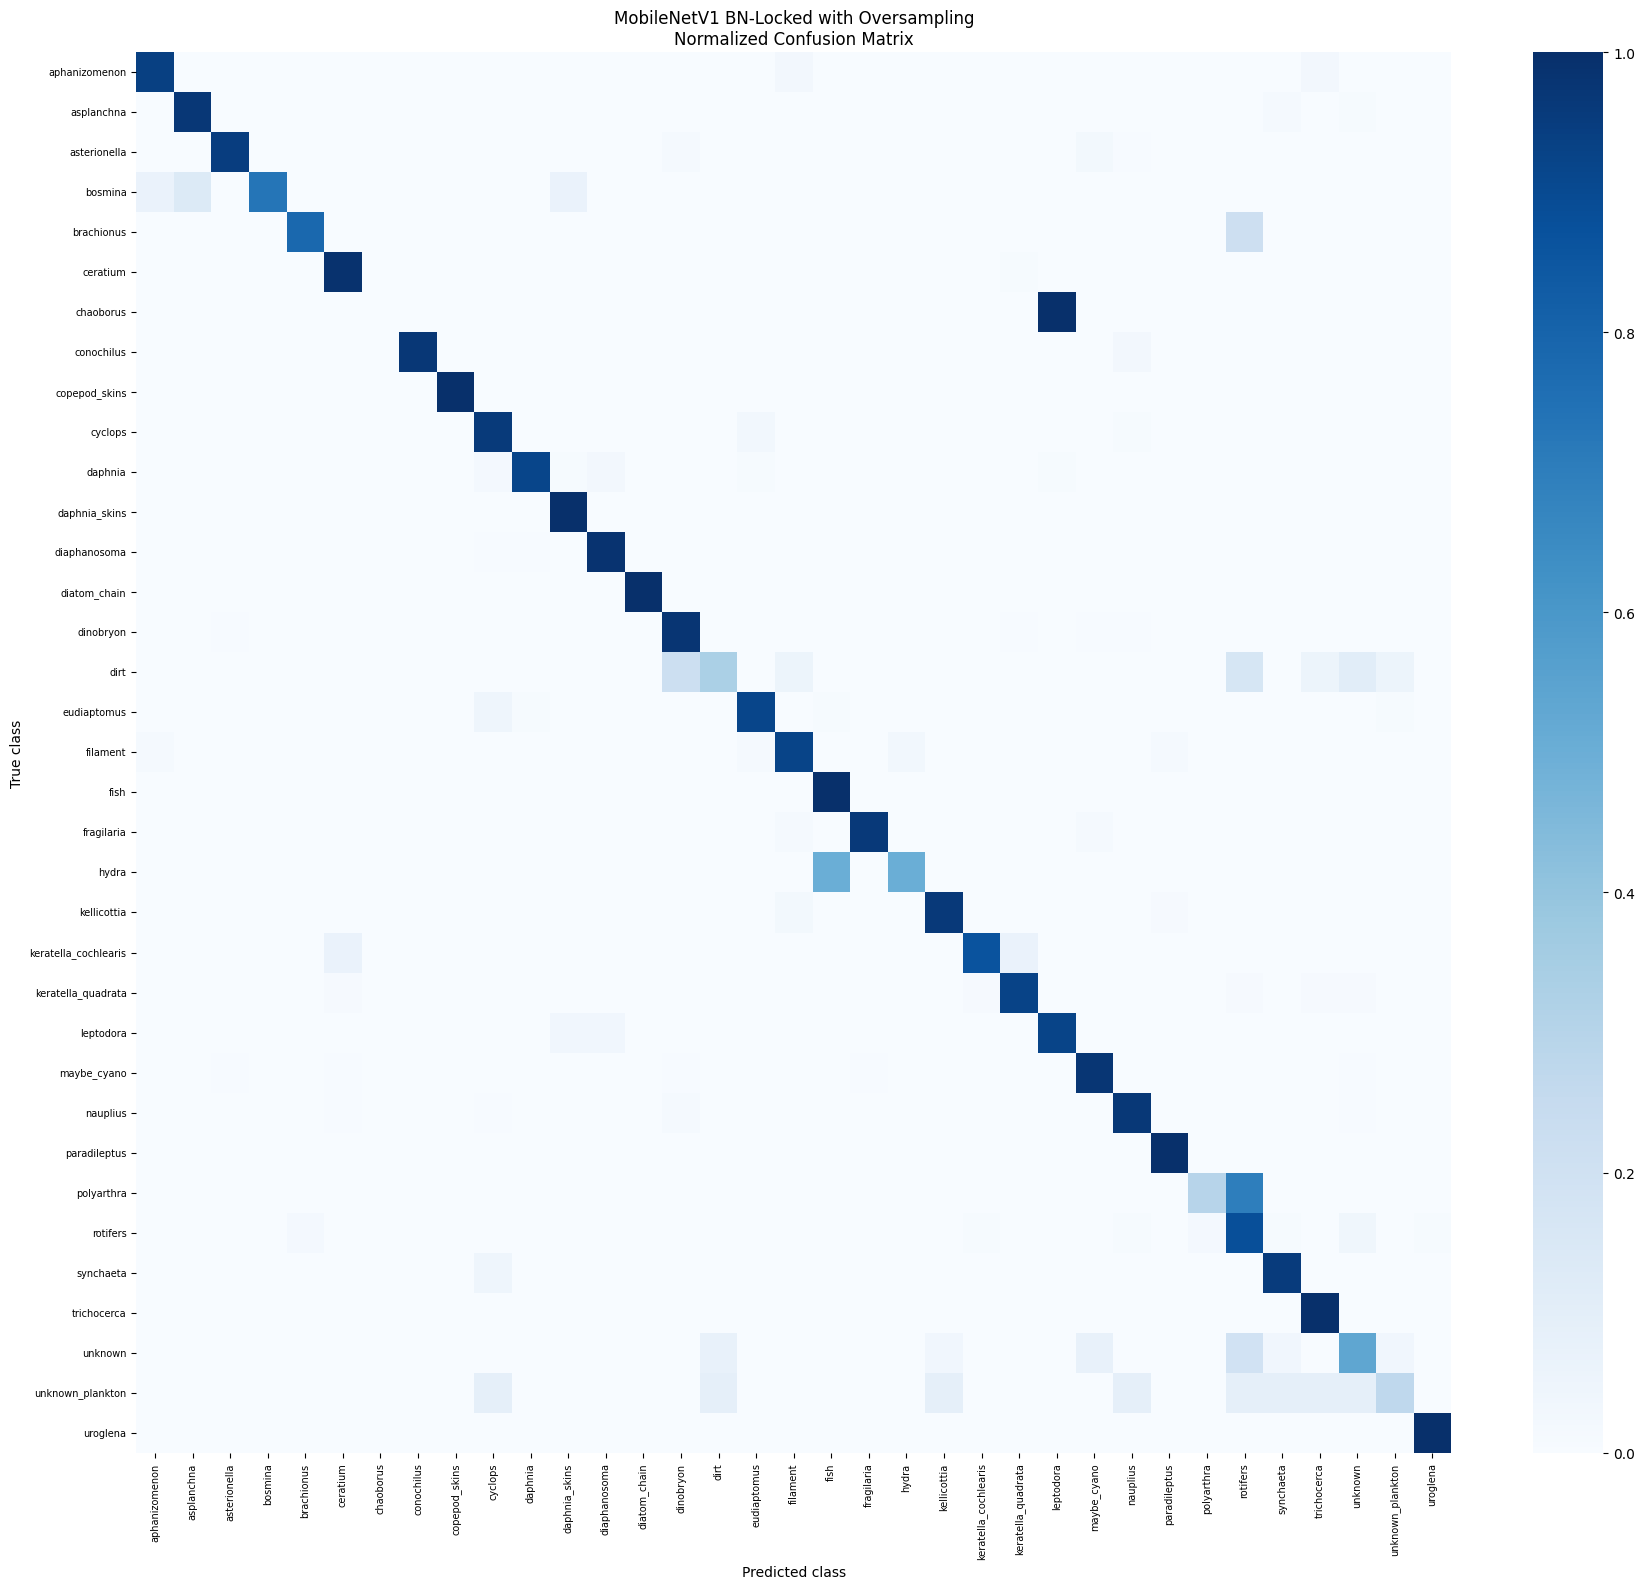

In [10]:
matrix_counts = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=np.arange(NUM_CLASSES),
)


matrix_normalized = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=np.arange(NUM_CLASSES),
    normalize="true",
)


pd.DataFrame(
    matrix_counts,
    index=class_names,
    columns=class_names,
).to_csv(
    OUTPUT_DIR / "confusion_matrix_counts.csv"
)


pd.DataFrame(
    matrix_normalized,
    index=class_names,
    columns=class_names,
).to_csv(
    OUTPUT_DIR / "confusion_matrix_normalized.csv"
)


plt.figure(
    figsize=(18, 16)
)

sns.heatmap(
    matrix_normalized,
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
)

plt.title(
    "MobileNetV1 BN-Locked with Oversampling\n"
    "Normalized Confusion Matrix"
)

plt.xlabel("Predicted class")
plt.ylabel("True class")

plt.xticks(
    rotation=90,
    fontsize=7,
)

plt.yticks(
    rotation=0,
    fontsize=7,
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "confusion_matrix_normalized.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

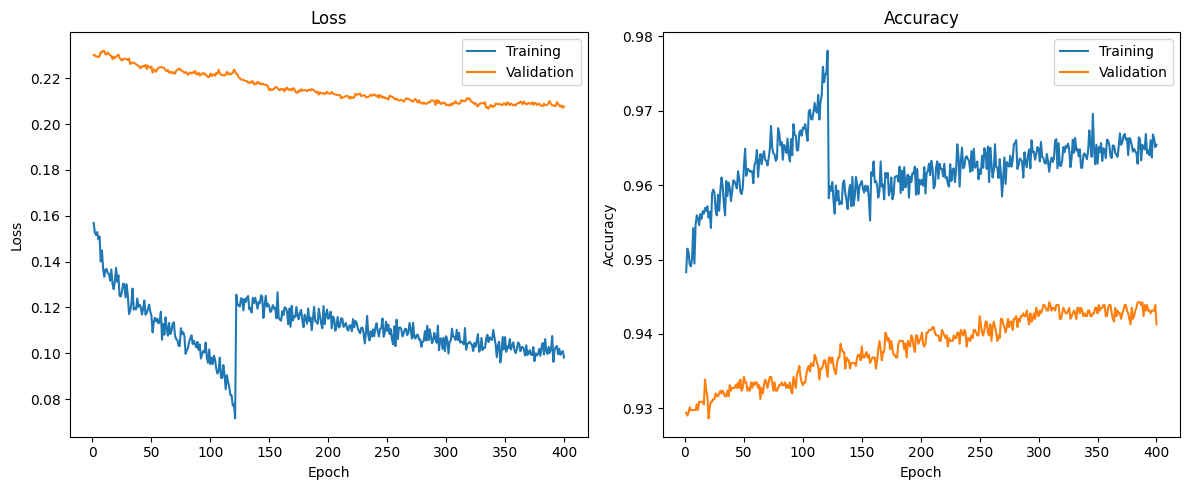

In [11]:
epochs = range(
    1,
    len(history_df) + 1,
)


plt.figure(
    figsize=(12, 5)
)


plt.subplot(1, 2, 1)

plt.plot(
    epochs,
    history_df["loss"],
    label="Training",
)

plt.plot(
    epochs,
    history_df["val_loss"],
    label="Validation",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()


plt.subplot(1, 2, 2)

plt.plot(
    epochs,
    history_df["accuracy"],
    label="Training",
)

plt.plot(
    epochs,
    history_df["val_accuracy"],
    label="Validation",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()


plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "training_curves.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

In [12]:
run_config = {
    "run_name": RUN_NAME,
    "model": "MobileNetV1",
    "training_stage": "BN-locked fine-tuning",
    "starting_model": str(FROZEN_MODEL_PATH),
    "oversampling": True,
    "rare_classes": rare_classes,
    "oversampling_target": target_count,
    "original_training_images": len(train_df),
    "oversampled_training_images": len(
        oversampled_train_df
    ),
    "validation_images": len(validation_df),
    "test_images": len(test_df),
    "seed": SEED,
    "image_size": list(IMAGE_SIZE),
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "maximum_epochs": EPOCHS,
    "patience": PATIENCE,
    "trainable_bn_layers": 0,
}


with open(
    OUTPUT_DIR / "run_config.json",
    "w",
) as file:
    json.dump(
        run_config,
        file,
        indent=2,
    )


pd.DataFrame(
    [test_metrics]
).to_csv(
    OUTPUT_DIR / "summary_metrics.csv",
    index=False,
)


with open(
    OUTPUT_DIR / "model_summary.txt",
    "w",
) as file:

    model.summary(
        print_fn=lambda line: file.write(
            line + "\n"
        )
    )


print("Αποθηκεύτηκαν οι ρυθμίσεις και τα αποτελέσματα.")

Αποθηκεύτηκαν οι ρυθμίσεις και τα αποτελέσματα.


In [13]:
ZIP_PATH = shutil.make_archive(
    str(
        Path("/kaggle/working")
        / f"{RUN_NAME}_results"
    ),
    "zip",
    root_dir=OUTPUT_DIR,
)


print("ZIP:")
print(ZIP_PATH)

print("\nΑρχεία:")

for path in sorted(
    OUTPUT_DIR.iterdir()
):
    print("-", path.name)

ZIP:
/kaggle/working/mobilenet_bn_locked_oversampling_seed12345_results.zip

Αρχεία:
- best_bn_locked.weights.h5
- best_bn_locked_model.keras
- bn_locked_history.csv
- classification_report.csv
- confusion_matrix_counts.csv
- confusion_matrix_normalized.csv
- confusion_matrix_normalized.png
- model_summary.txt
- oversampling_counts.csv
- predictions.npz
- run_config.json
- summary_metrics.csv
- test_metrics.json
- test_predictions.csv
- training_curves.png
